# 🎓 Student Performance Prediction
### Machine Learning Project | Python · Scikit-learn · Matplotlib · Seaborn

---

**Objective:** Predict a student's final exam score using features like study time, attendance, previous scores, sleep hours, and more.

**Pipeline:**
1. Dataset Generation
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing (Missing Values, Normalization, Feature Engineering)
4. Feature Selection
5. Model Training — Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting
6. Model Evaluation — RMSE, MAE, R², Accuracy, 5-Fold Cross-Validation
7. Visualizations — Heatmap, Scatter, Feature Importance, Predicted vs Actual, Residuals
8. Prediction on New Students

---
## 📦 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE = 'coolwarm'
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📊 2. Dataset Generation

Generating a realistic synthetic dataset of **1000 students** with properly scaled scores (0–100).

In [2]:
np.random.seed(42)
N = 1000

# Feature generation
study_time   = np.random.uniform(1, 10, N)
attendance   = np.random.uniform(40, 100, N)
prev_score   = np.random.uniform(30, 100, N)
sleep_hours  = np.random.uniform(4, 10, N)
assignments  = np.random.uniform(0, 100, N)
parental_edu = np.random.randint(0, 4, N)    # 0=None,1=HS,2=UG,3=PG
extra_class  = np.random.randint(0, 2, N)    # 0=No, 1=Yes
internet     = np.random.randint(0, 2, N)    # 0=No, 1=Yes

# FIXED: Properly scaled score formula so high performers score 80-95+
noise = np.random.normal(0, 4, N)
raw_score = (
    0.35 * prev_score                    # strongest predictor
    + 0.25 * (study_time / 10) * 100    # normalized study time
    + 0.20 * attendance                  # attendance %
    + 0.10 * assignments                 # assignments %
    + 0.04 * (sleep_hours / 10) * 100   # sleep contribution
    + 0.03 * parental_edu * 10          # parental education
    + 0.02 * extra_class * 15           # extra classes
    + 0.01 * internet * 10              # internet access
    + noise
)

# Scale to realistic 0-100 range
final_score = np.interp(raw_score, (raw_score.min(), raw_score.max()), (10, 98))
final_score = np.clip(final_score, 0, 100)

df = pd.DataFrame({
    'study_time_hrs':  np.round(study_time, 2),
    'attendance_pct':  np.round(attendance, 2),
    'prev_score':      np.round(prev_score, 2),
    'sleep_hours':     np.round(sleep_hours, 2),
    'assignments_pct': np.round(assignments, 2),
    'parental_edu':    parental_edu,
    'extra_classes':   extra_class,
    'internet_access': internet,
    'final_score':     np.round(final_score, 2),
})

# Introduce ~5% missing values in 3 columns
for col in ['study_time_hrs', 'sleep_hours', 'assignments_pct']:
    mask = np.random.choice([True, False], size=N, p=[0.05, 0.95])
    df.loc[mask, col] = np.nan

print(f'Dataset shape  : {df.shape}')
print(f'Score range    : {df.final_score.min():.1f} – {df.final_score.max():.1f}')
print(f'Score mean     : {df.final_score.mean():.1f}')
df.head(10)

Dataset shape  : (1000, 9)
Score range    : 10.0 – 98.0
Score mean     : 54.7


,study_time_hrs,attendance_pct,prev_score,sleep_hours,assignments_pct,parental_edu,extra_classes,internet_access,final_score
0,4.37,51.11,48.32,8.04,57.20,2,1,0,37.95
1,9.56,72.51,47.29,8.78,80.54,3,0,0,66.97
2,7.59,92.38,93.44,5.50,76.02,2,1,0,86.87
3,6.39,83.93,47.47,7.75,15.39,3,0,0,49.95
4,2.40,88.39,49.04,7.43,14.92,3,0,0,39.59
5,2.40,79.53,83.16,9.00,26.82,2,0,0,58.39
6,1.52,81.54,61.48,9.44,36.11,1,0,1,43.86
7,8.80,90.95,84.37,4.07,40.85,3,0,1,82.33
8,6.41,54.98,34.58,8.04,67.97,2,1,0,33.58
9,7.37,69.37,64.13,4.31,5.67,0,1,0,53.12


---
## 🔍 3. Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Info ===')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
print(f'\nMissing Values:')
print(df.isnull().sum().to_string())

=== Dataset Info ===
Rows: 1000  |  Columns: 9

Missing Values:
study_time_hrs     56
attendance_pct      0
prev_score          0
sleep_hours        51
assignments_pct    53
parental_edu        0
extra_classes       0
internet_access     0
final_score         0


In [4]:
df.describe().round(2)

,study_time_hrs,attendance_pct,prev_score,sleep_hours,assignments_pct,parental_edu,extra_classes,internet_access,final_score
count,944.00,1000.00,1000.00,949.00,947.00,1000.00,1000.00,1000.00,1000.00
mean,5.38,70.42,65.17,6.93,49.67,1.50,0.49,0.52,54.66
std,2.62,17.53,20.35,1.72,28.73,1.12,0.50,0.50,16.47
min,1.04,40.19,30.00,4.00,0.00,0.00,0.00,0.00,10.00
25%,3.06,54.46,48.30,5.45,24.78,1.00,0.00,0.00,43.08
50%,5.44,71.12,65.04,6.86,50.03,1.00,0.00,1.00,54.68
75%,7.63,85.63,83.14,8.41,74.22,3.00,1.00,1.00,66.71
max,10.00,99.96,99.85,10.00,99.77,3.00,1.00,1.00,98.00


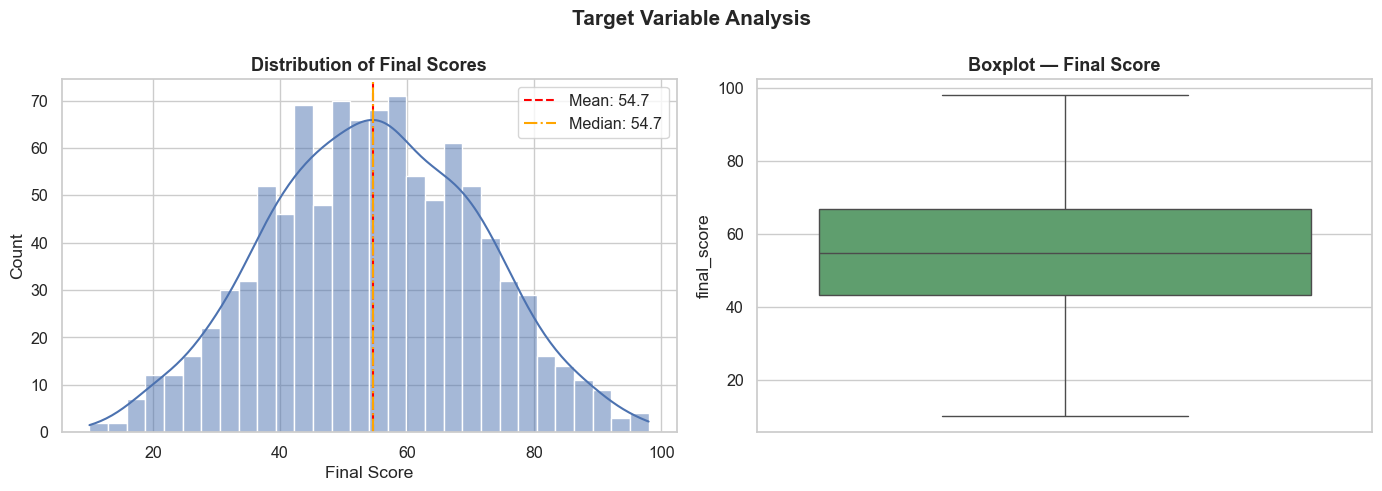

In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['final_score'], kde=True, color='#4C72B0', bins=30, ax=axes[0])
axes[0].set_title('Distribution of Final Scores', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Final Score')
axes[0].axvline(df['final_score'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['final_score'].mean():.1f}")
axes[0].axvline(df['final_score'].median(), color='orange', linestyle='-.',
                label=f"Median: {df['final_score'].median():.1f}")
axes[0].legend()

sns.boxplot(y=df['final_score'], color='#55A868', ax=axes[1])
axes[1].set_title('Boxplot — Final Score', fontsize=13, fontweight='bold')
plt.suptitle('Target Variable Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

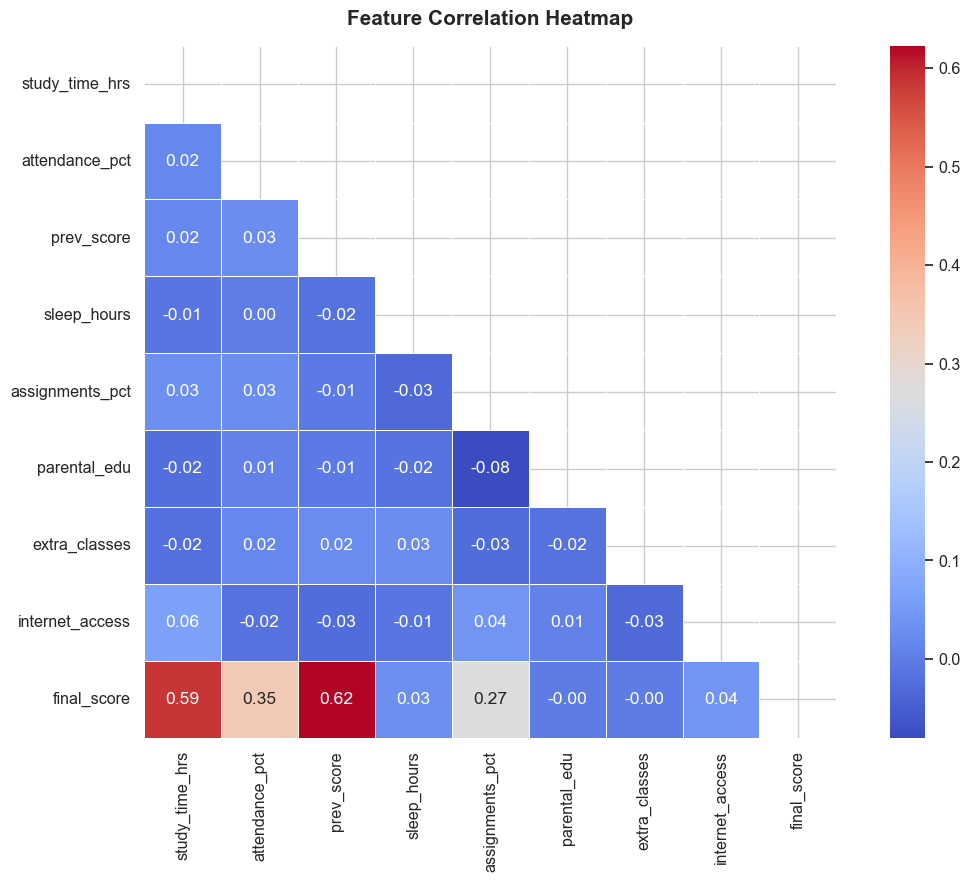

In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=PALETTE, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

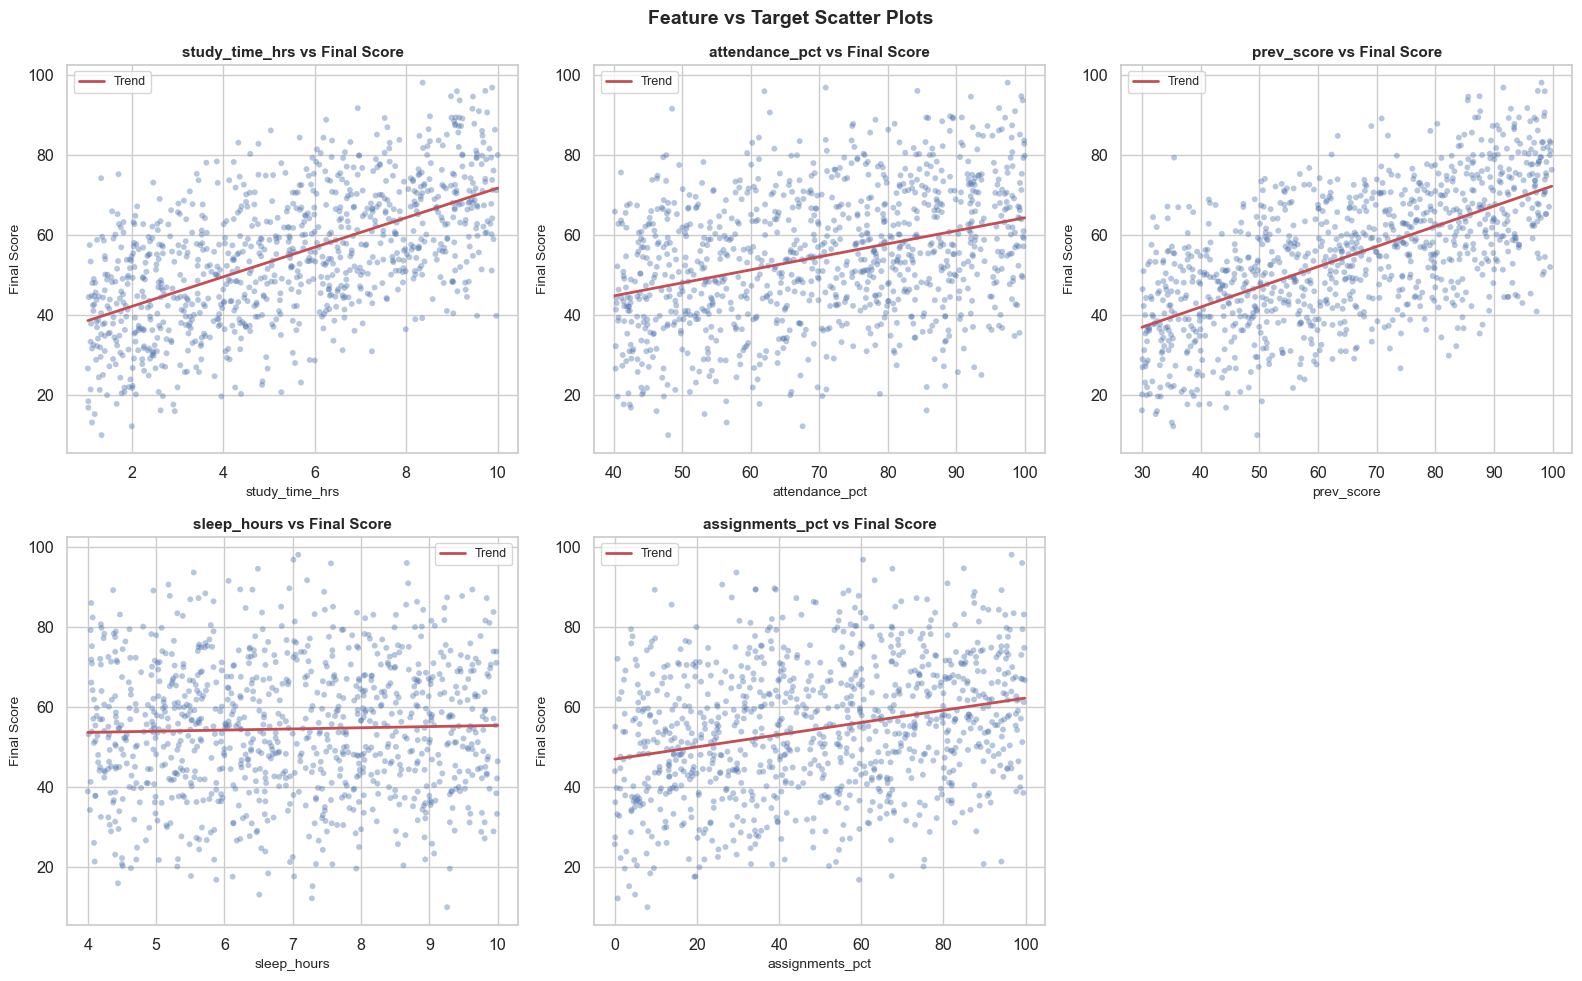

In [7]:
# Feature vs Target scatter
cont_features = ['study_time_hrs', 'attendance_pct', 'prev_score', 'sleep_hours', 'assignments_pct']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, feat in enumerate(cont_features):
    valid = df[[feat, 'final_score']].dropna()
    axes[i].scatter(valid[feat], valid['final_score'], alpha=0.4, s=18,
                    color='#4C72B0', edgecolors='none')
    m, b = np.polyfit(valid[feat], valid['final_score'], 1)
    xs = np.linspace(valid[feat].min(), valid[feat].max(), 100)
    axes[i].plot(xs, m*xs + b, color='#C44E52', linewidth=2, label='Trend')
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('Final Score', fontsize=10)
    axes[i].set_title(f'{feat} vs Final Score', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Feature vs Target Scatter Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

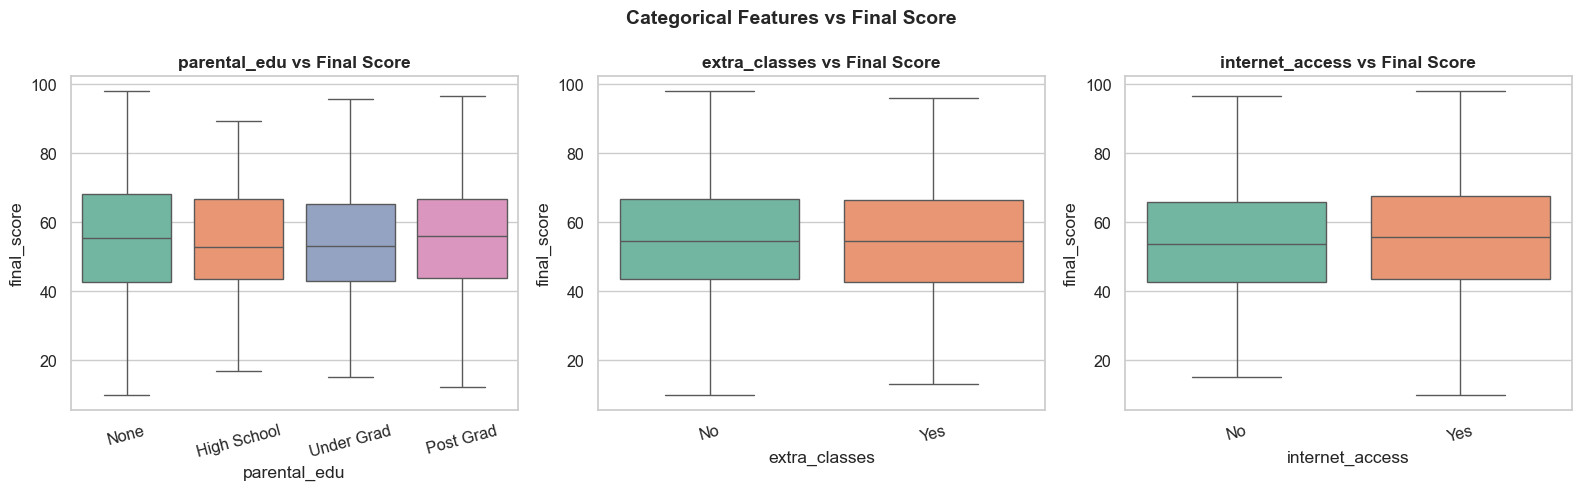

In [8]:
# Categorical features
cat_features = ['parental_edu', 'extra_classes', 'internet_access']
labels = {
    'parental_edu':    ['None', 'High School', 'Under Grad', 'Post Grad'],
    'extra_classes':   ['No', 'Yes'],
    'internet_access': ['No', 'Yes'],
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, cat_features):
    sns.boxplot(x=feat, y='final_score', data=df, palette='Set2', ax=ax)
    ax.set_title(f'{feat} vs Final Score', fontweight='bold')
    if feat in labels:
        ax.set_xticklabels(labels[feat], rotation=15)
plt.suptitle('Categorical Features vs Final Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🧹 4. Data Preprocessing

**Steps:** Handle missing values → Feature engineering → Train/Test split → Feature selection → Normalization

In [9]:
# 4.1 Handle Missing Values — Median Imputation
df_clean = df.copy()
print('Missing Value Imputation (Median):')
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().any():
        mv = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(mv)
        print(f"  '{col}' → filled {df[col].isnull().sum()} NaN  |  median = {mv:.2f}")
print(f'\nTotal missing after imputation: {df_clean.isnull().sum().sum()}')

Missing Value Imputation (Median):
  'study_time_hrs' → filled 56 NaN  |  median = 5.45
  'sleep_hours' → filled 51 NaN  |  median = 6.86
  'assignments_pct' → filled 53 NaN  |  median = 50.03

Total missing after imputation: 0


In [10]:
# 4.2 Feature Engineering
df_clean['study_attend_ratio'] = df_clean['study_time_hrs'] / (df_clean['attendance_pct'] / 100 + 1e-6)
df_clean['overall_index']      = (df_clean['prev_score'] + df_clean['assignments_pct']) / 2
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))
print('Feature Engineering:')
print('  study_attend_ratio  =  study_time / (attendance / 100)')
print('  overall_index       =  (prev_score + assignments_pct) / 2')
print(f'\nTotal features: {df_clean.shape[1] - 1}  |  Target: final_score')

Feature Engineering:
  study_attend_ratio  =  study_time / (attendance / 100)
  overall_index       =  (prev_score + assignments_pct) / 2

Total features: 10  |  Target: final_score


In [11]:
# 4.3 Train / Test Split (80-20)
TARGET   = 'final_score'
FEATURES = [c for c in df_clean.columns if c != TARGET]
X, y = df_clean[FEATURES], df_clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples  (20%)')

Train : 800 samples
Test  : 200 samples  (20%)


In [12]:
# 4.4 Feature Selection — SelectKBest (ANOVA F-value)
selector = SelectKBest(f_regression, k=8)
X_train_sel = pd.DataFrame(selector.fit_transform(X_train, y_train),
                            columns=X_train.columns[selector.get_support()])
X_test_sel  = pd.DataFrame(selector.transform(X_test),
                            columns=X_train_sel.columns)
selected_features = X_train_sel.columns.tolist()
scores = selector.scores_[selector.get_support()]

print(f'Top {len(selected_features)} features by F-score:')
for f, s in sorted(zip(selected_features, scores), key=lambda x: -x[1]):
    print(f'  {f:<28}  F-score: {s:.2f}')

Top 8 features by F-score:
  prev_score                    F-score: 481.63
  overall_index                 F-score: 377.35
  study_time_hrs                F-score: 350.95
  attendance_pct                F-score: 117.11
  study_attend_ratio            F-score: 76.20
  assignments_pct               F-score: 56.62
  sleep_hours                   F-score: 2.13
  internet_access               F-score: 0.78


In [13]:
# 4.5 Normalization — MinMaxScaler
scaler = MinMaxScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_sel), columns=selected_features)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_sel),      columns=selected_features)
y_train    = y_train.reset_index(drop=True)
y_test     = y_test.reset_index(drop=True)
print('✅ Preprocessing complete!')
print(f'   X_train: {X_train_sc.shape}  |  X_test: {X_test_sc.shape}')
X_train_sc.head(3)

✅ Preprocessing complete!
   X_train: (800, 8)  |  X_test: (200, 8)


,study_time_hrs,attendance_pct,prev_score,sleep_hours,assignments_pct,internet_access,study_attend_ratio,overall_index
0,0.042411,0.828844,0.656654,0.632107,0.362057,1.0,0.019353,0.478102
1,0.944196,0.119123,0.837741,0.128763,0.590539,0.0,0.872961,0.692826
2,0.609375,0.065250,0.520696,0.028428,0.883700,1.0,0.626642,0.736136


---
## 🤖 5. Model Training

Training **6 models** with 5-fold cross-validation.

In [14]:
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Lasso Regression':   Lasso(alpha=0.1),
    'Decision Tree':      DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                                     max_depth=4, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results, trained_models = [], {}

print(f'{"Model":<22} {"RMSE":>8} {"MAE":>8} {"R²":>8} {"Accuracy":>10} {"CV-RMSE":>10}')
print('─' * 72)

for name, model in models.items():
    cv_rmse = -cross_val_score(model, X_train_sc, y_train,
                               scoring='neg_root_mean_squared_error', cv=kf).mean()
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    trained_models[name] = (model, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    acc  = max(0, 100 - rmse)

    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae,
                    'R2': r2, 'Accuracy': acc, 'CV_RMSE': cv_rmse})
    print(f'{name:<22} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f} {acc:>9.2f}% {cv_rmse:>10.4f}')

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

Model                      RMSE      MAE       R²   Accuracy    CV-RMSE
────────────────────────────────────────────────────────────────────────
Linear Regression        5.6763   4.4355   0.8833     94.32%     6.2244
Ridge Regression         5.6700   4.4191   0.8836     94.33%     6.2252
Lasso Regression         5.6706   4.4393   0.8836     94.33%     6.2673
Decision Tree            9.0792   7.4173   0.7015     90.92%     9.1427
Random Forest            6.7195   5.2310   0.8365     93.28%     7.0717
Gradient Boosting        6.4281   5.1359   0.8504     93.57%     6.9029


---
## 📈 6. Model Evaluation & Results

In [15]:
results_df.style \
    .background_gradient(subset=['R2'],        cmap='Greens') \
    .background_gradient(subset=['RMSE','MAE'], cmap='Reds_r') \
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}','R2':'{:.4f}',
             'Accuracy':'{:.2f}%','CV_RMSE':'{:.4f}'})

,Model,RMSE,MAE,R2,Accuracy,CV_RMSE
0,Ridge Regression,5.6700,4.4191,0.8836,94.33%,6.2252
1,Lasso Regression,5.6706,4.4393,0.8836,94.33%,6.2673
2,Linear Regression,5.6763,4.4355,0.8833,94.32%,6.2244
3,Gradient Boosting,6.4281,5.1359,0.8504,93.57%,6.9029
4,Random Forest,6.7195,5.2310,0.8365,93.28%,7.0717
5,Decision Tree,9.0792,7.4173,0.7015,90.92%,9.1427


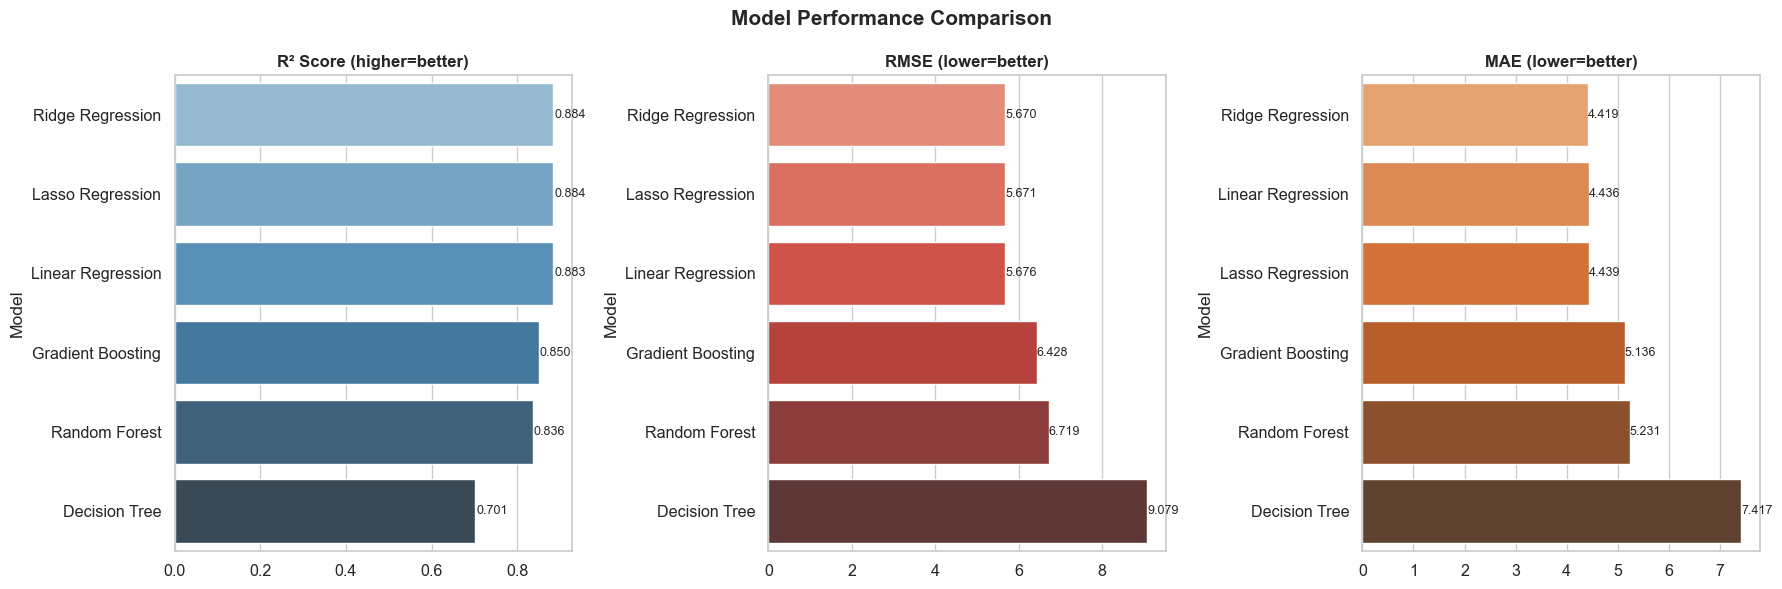

In [16]:
# Model comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = [('R2','R² Score (higher=better)','Blues_d'),
           ('RMSE','RMSE (lower=better)','Reds_d'),
           ('MAE','MAE (lower=better)','Oranges_d')]
for ax, (col, label, pal) in zip(axes, metrics):
    data = results_df.sort_values(col, ascending=(col != 'R2'))
    sns.barplot(x=col, y='Model', data=data, palette=pal, ax=ax)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    for bar in ax.patches:
        ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=9)
plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎨 7. Visualizations

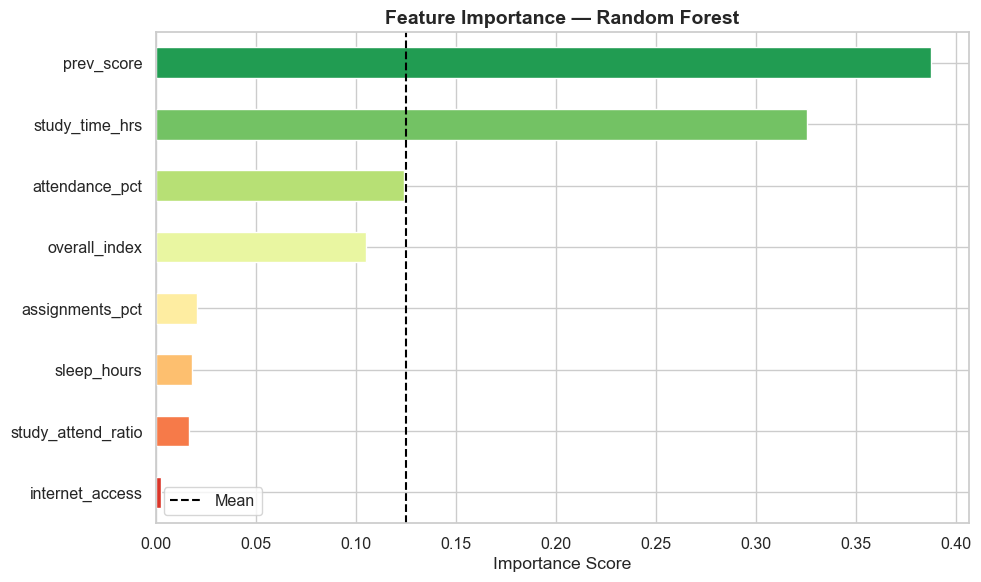

In [17]:
# Feature Importance (Random Forest)
rf_model = trained_models['Random Forest'][0]
importance = pd.Series(rf_model.feature_importances_, index=selected_features).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind='barh', color=sns.color_palette('RdYlGn', len(importance)),
                edgecolor='white', ax=ax)
ax.axvline(importance.mean(), color='black', linestyle='--', linewidth=1.5, label='Mean')
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.show()

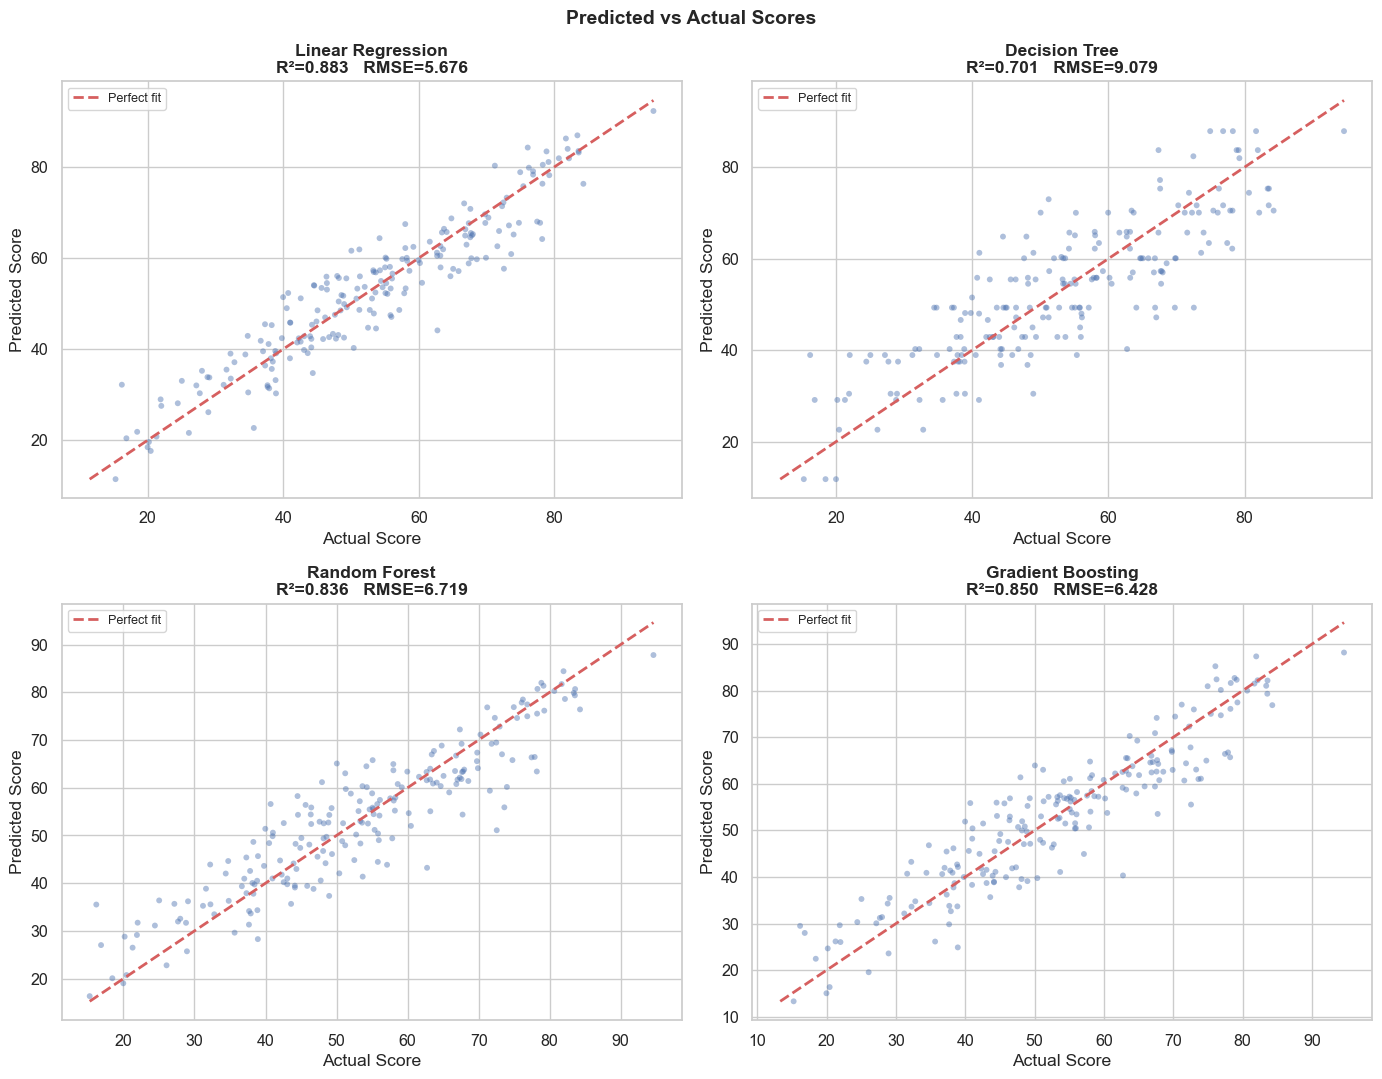

In [18]:
# Predicted vs Actual — 4 models
plot_models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
for i, name in enumerate(plot_models):
    _, y_pred = trained_models[name]
    axes[i].scatter(y_test, y_pred, alpha=0.45, s=18, color='#4C72B0', edgecolors='none')
    lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    axes[i].plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect fit')
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    axes[i].set_title(f'{name}\nR²={r2:.3f}   RMSE={rmse:.3f}', fontweight='bold')
    axes[i].set_xlabel('Actual Score'); axes[i].set_ylabel('Predicted Score')
    axes[i].legend(fontsize=9)
plt.suptitle('Predicted vs Actual Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

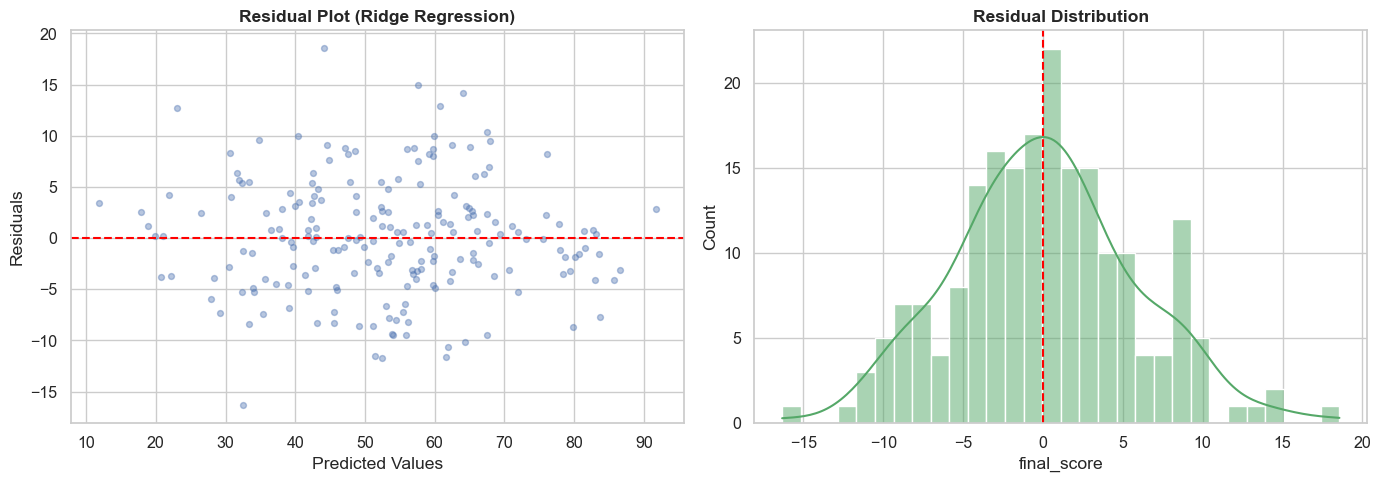

In [19]:
# Residuals Analysis
best_name = results_df.iloc[0]['Model']
_, y_pred_best = trained_models[best_name]
residuals = y_test - y_pred_best
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_best, residuals, alpha=0.4, s=18, color='#4C72B0')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Values'); axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residual Plot ({best_name})', fontweight='bold')
sns.histplot(residuals, kde=True, color='#55A868', bins=30, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

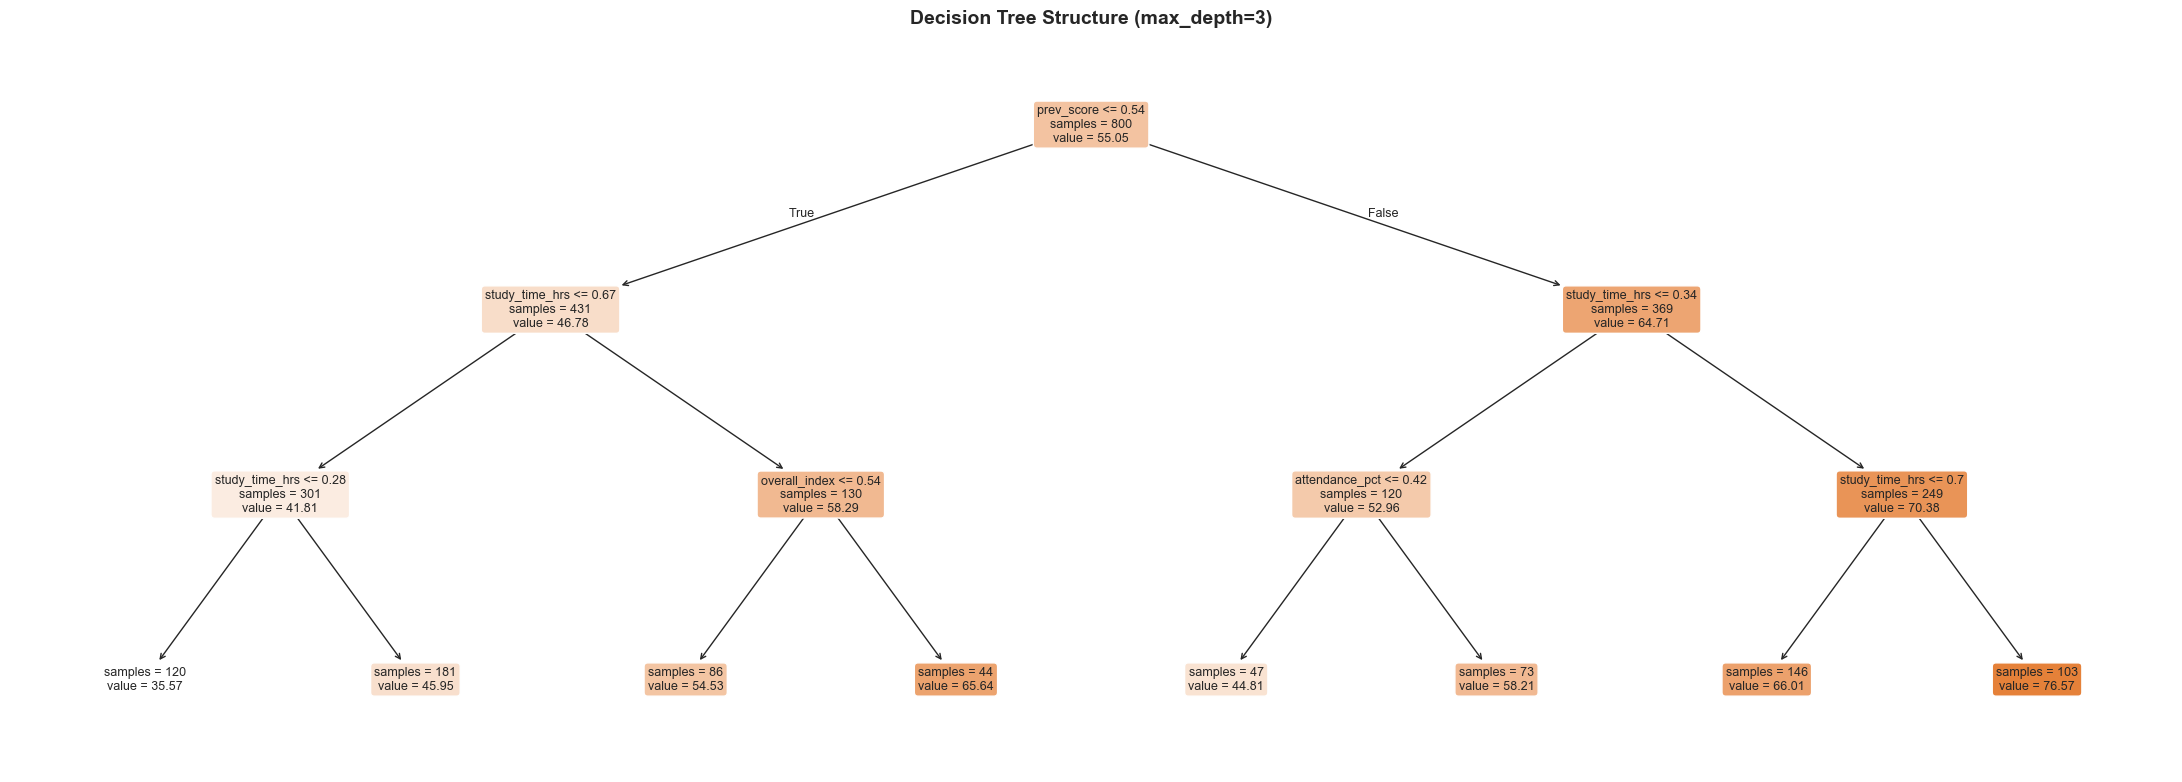

In [20]:
# Decision Tree Structure
dt_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_viz.fit(X_train_sc, y_train)
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt_viz, feature_names=selected_features, filled=True,
          rounded=True, fontsize=9, ax=ax, max_depth=3, impurity=False, precision=2)
ax.set_title('Decision Tree Structure (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

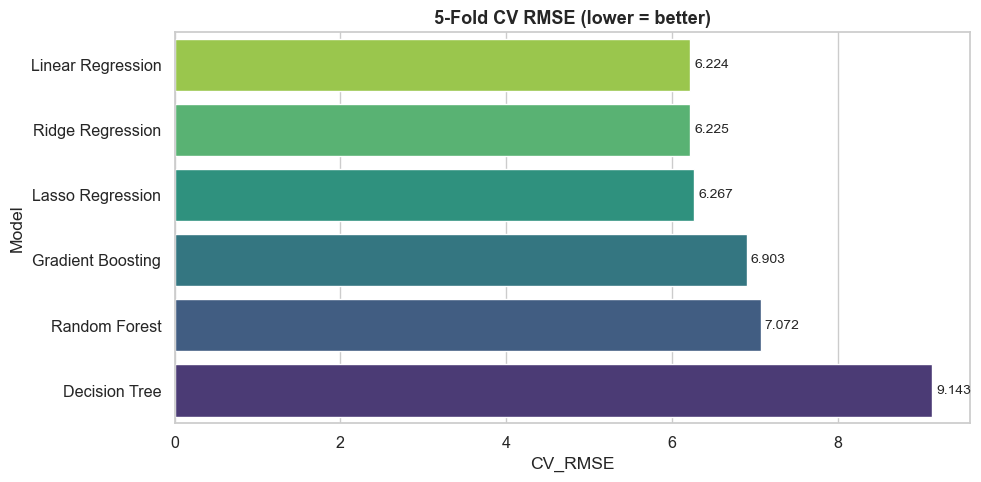

In [21]:
# 5-Fold Cross-Validation RMSE
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = results_df.sort_values('CV_RMSE')
sns.barplot(x='CV_RMSE', y='Model', data=cv_data, palette='viridis_r', ax=ax)
for bar in ax.patches:
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=10)
ax.set_title('5-Fold CV RMSE (lower = better)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔮 8. Predict New Students

In [22]:
def predict_student(study_time_hrs, attendance_pct, prev_score, sleep_hours,
                    assignments_pct, parental_edu, extra_classes, internet_access,
                    model_name=None):
    if model_name is None:
        model_name = results_df.iloc[0]['Model']  # Use best model automatically
    raw = pd.DataFrame([{
        'study_time_hrs': study_time_hrs, 'attendance_pct': attendance_pct,
        'prev_score': prev_score,         'sleep_hours': sleep_hours,
        'assignments_pct': assignments_pct, 'parental_edu': parental_edu,
        'extra_classes': extra_classes,   'internet_access': internet_access,
    }])
    raw['study_attend_ratio'] = raw['study_time_hrs'] / (raw['attendance_pct'] / 100 + 1e-6)
    raw['overall_index']      = (raw['prev_score'] + raw['assignments_pct']) / 2
    X_sel    = pd.DataFrame(selector.transform(raw), columns=selected_features)
    X_scaled = pd.DataFrame(scaler.transform(X_sel),  columns=selected_features)
    model, _ = trained_models[model_name]
    score    = float(np.clip(model.predict(X_scaled)[0], 0, 100))
    grade    = 'A' if score>=80 else 'B' if score>=65 else 'C' if score>=50 else 'D' if score>=35 else 'F'
    print(f'  Model           : {model_name}')
    print(f'  Predicted Score : {score:.2f} / 100')
    print(f'  Grade           : {grade}')
    return score

print('='*50)
print('  STUDENT 1 — High Performer')
print('='*50)
predict_student(study_time_hrs=8, attendance_pct=95, prev_score=88,
                sleep_hours=7.5, assignments_pct=92,
                parental_edu=3, extra_classes=1, internet_access=1)

print()
print('='*50)
print('  STUDENT 2 — Average Student')
print('='*50)
predict_student(study_time_hrs=5, attendance_pct=75, prev_score=62,
                sleep_hours=7, assignments_pct=68,
                parental_edu=2, extra_classes=0, internet_access=1)

print()
print('='*50)
print('  STUDENT 3 — At-Risk Student')
print('='*50)
predict_student(study_time_hrs=2, attendance_pct=50, prev_score=38,
                sleep_hours=5, assignments_pct=30,
                parental_edu=0, extra_classes=0, internet_access=0)

  STUDENT 1 — High Performer
  Model           : Ridge Regression
  Predicted Score : 88.61 / 100
  Grade           : A

  STUDENT 2 — Average Student
  Model           : Ridge Regression
  Predicted Score : 55.90 / 100
  Grade           : C

  STUDENT 3 — At-Risk Student
  Model           : Ridge Regression
  Predicted Score : 18.89 / 100
  Grade           : F


18.894914373619777

---
## 📋 9. Final Summary

In [23]:
best = results_df.iloc[0]
print('╔══════════════════════════════════════════════════╗')
print('║        PROJECT SUMMARY — KEY RESULTS             ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  Dataset        : 1000 students, 8 features      ║')
print(f'║  Train / Test   : 800 / 200  (80-20 split)       ║')
print(f'║  Models Trained : 6                              ║')
print(f'║  Best Model     : {best["Model"]:<30} ║')
print(f'║  Best R²        : {best["R2"]:.4f}                           ║')
print(f'║  Best RMSE      : {best["RMSE"]:.4f}                           ║')
print(f'║  Accuracy       : {best["Accuracy"]:.2f}%                          ║')
print(f'║  CV-RMSE        : {best["CV_RMSE"]:.4f}  (5-fold)               ║')
print('╚══════════════════════════════════════════════════╝')
print()
print('📌 Feature Importance (Random Forest):')
for feat, imp in importance.sort_values(ascending=False).items():
    bar = '█' * int(imp * 100)
    print(f'   {feat:<28}  {imp:.4f}  {bar}')

╔══════════════════════════════════════════════════╗
║        PROJECT SUMMARY — KEY RESULTS             ║
╠══════════════════════════════════════════════════╣
║  Dataset        : 1000 students, 8 features      ║
║  Train / Test   : 800 / 200  (80-20 split)       ║
║  Models Trained : 6                              ║
║  Best Model     : Ridge Regression               ║
║  Best R²        : 0.8836                           ║
║  Best RMSE      : 5.6700                           ║
║  Accuracy       : 94.33%                          ║
║  CV-RMSE        : 6.2252  (5-fold)               ║
╚══════════════════════════════════════════════════╝

📌 Feature Importance (Random Forest):
   prev_score                    0.3873  ██████████████████████████████████████
   study_time_hrs                0.3254  ████████████████████████████████
   attendance_pct                0.1243  ████████████
   overall_index                 0.1049  ██████████
   assignments_pct               0.0205  ██
   sleep_hours  